# Second-Difference Penalty: Eigenvectors and Hill Function Reconstruction

This short handout illustrates what happens when a least-squares problem is regularized by a second-difference penalty. The grid is

$$x = 0, 0.01, 0.02, \ldots, 1.00.$$

This gives 101 grid points and 100 equal subintervals. Let $n$ be the number of grid points. Define the second-difference matrix $\Gamma \in \mathbb{R}^{(n-2)\times n}$ by

$$\Gamma_{i,j}=\delta_{i,j}-2\delta_{i,j+1}+\delta_{i,j+2},$$

where $i=0,\ldots,n-3$ and $j=0,\ldots,n-1$. Applying $\Gamma$ to a vector computes consecutive second differences:

$$(\Gamma f)_i = f_i - 2f_{i+1} + f_{i+2}.$$

If a least-squares objective includes the penalty

$$\lambda \|\Gamma f\|_2^2,$$

then the quadratic penalty matrix is $\Gamma^T\Gamma$. Its eigenvectors form a useful basis for understanding which shapes are weakly or strongly penalized. Small eigenvalues correspond to smooth, slowly varying modes; large eigenvalues correspond to oscillatory modes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7, 4),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

## Build the second-difference matrix

The following cell constructs the grid, the matrix $\Gamma$, and the penalty matrix $\Gamma^T\Gamma$.

In [2]:
grid = np.arange(0, 1.00 + 0.01, 0.01)
n = len(grid)

Gamma = np.zeros((n - 2, n))
for i in range(n - 2):
    Gamma[i, i] = 1
    Gamma[i, i + 1] = -2
    Gamma[i, i + 2] = 1

penalty = Gamma.T @ Gamma

print(f"Number of grid points: {n}")
print(f"Gamma shape: {Gamma.shape}")
print(f"Gamma.T @ Gamma shape: {penalty.shape}")

Number of grid points: 101
Gamma shape: (99, 101)
Gamma.T @ Gamma shape: (101, 101)


## Eigenvalues and eigenvectors

We diagonalize $\Gamma^T\Gamma$, sort the eigenvalues from smallest to largest, and plot the first four eigenvectors. Because $\Gamma$ computes second differences, affine functions have zero second difference. Therefore the first two eigenvalues are numerically zero, corresponding approximately to constant and linear directions.

In [3]:
eigvals, eigvecs = np.linalg.eigh(penalty)
order = np.argsort(eigvals)
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# Choose a consistent sign convention so plots are easier to compare.
for k in range(eigvecs.shape[1]):
    if eigvecs[np.argmax(np.abs(eigvecs[:, k])), k] < 0:
        eigvecs[:, k] *= -1

pd.DataFrame({
    "mode": np.arange(1, 11),
    "eigenvalue": eigvals[:10],
})

,mode,eigenvalue
0,1,1.542839e-15
1,2,3.391977e-15
2,3,4.810814e-06
3,4,3.654250e-05
4,5,1.403463e-04
5,6,3.831296e-04
6,7,8.538436e-04
7,8,1.662921e-03
8,9,2.941799e-03
9,10,4.842301e-03


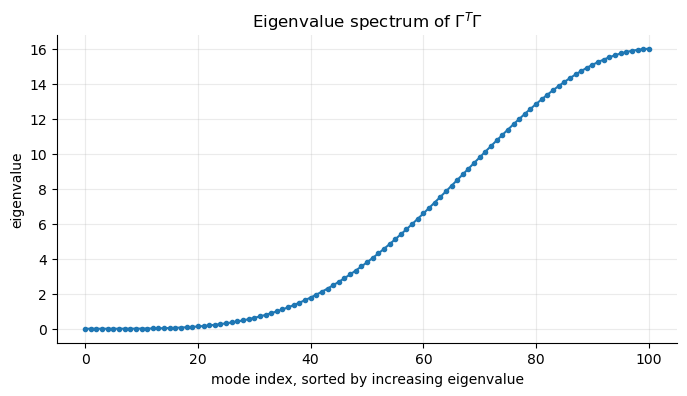

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
modes = np.arange(0, n)
ax.plot(modes, eigvals, marker="o", markersize=3, linewidth=1.5)
ax.set_xlabel("mode index, sorted by increasing eigenvalue")
ax.set_ylabel("eigenvalue")
ax.set_title("Eigenvalue spectrum of $\\Gamma^T\\Gamma$")
plt.show()

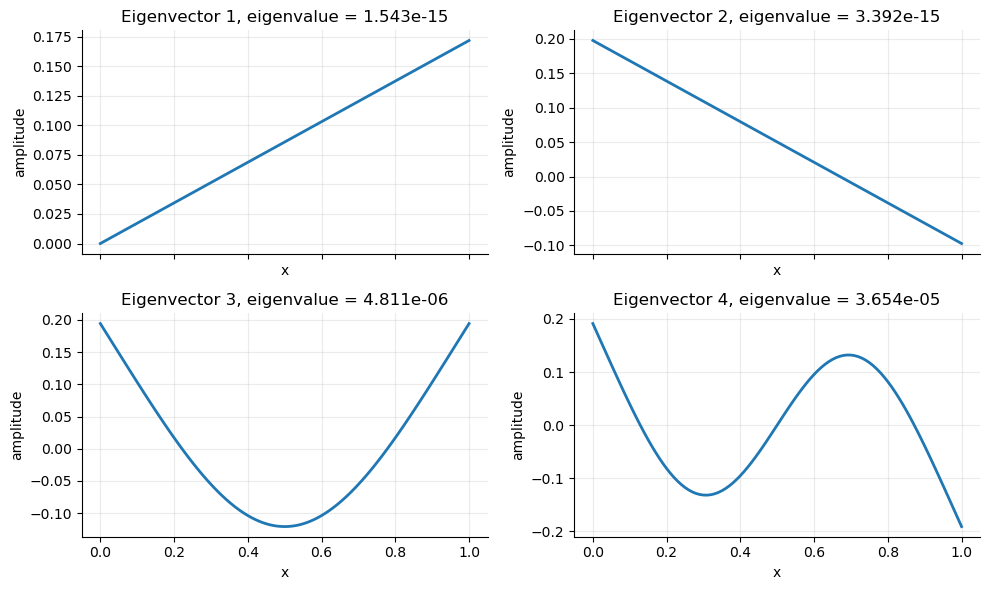

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
axes = axes.ravel()

for k, ax in enumerate(axes):
    ax.plot(grid, eigvecs[:, k], linewidth=2)
    ax.set_title(f"Eigenvector {k + 1}, eigenvalue = {eigvals[k]:.3e}")
    ax.set_xlabel("x")
    ax.set_ylabel("amplitude")

fig.tight_layout()
plt.show()

## Expand a Hill function in the eigenvector basis

Now consider the Hill function

$$h(x)=\frac{x^2}{K^2+x^2}, \qquad K=0.4.$$

On the grid $x=0,0.01,\ldots,1.00$, this function rises smoothly from 0 and approaches saturation. The eigenvectors of $\Gamma^T\Gamma$ are orthonormal, so the weight on eigenvector $v_k$ is simply

$$w_k = v_k^T h.$$

The reconstruction using the first $m$ eigenvectors is

$$h_m = \sum_{k=1}^m w_k v_k.$$

Below we list and plot the weights for all eigenvectors, then compare reconstructions using the first 2, 3, and 4 modes.

In [6]:
K = 0.4
hill = grid**2 / (K**2 + grid**2)

weights = eigvecs.T @ hill

weights_table = pd.DataFrame({
    "mode": np.arange(1, n + 1),
    "eigenvalue": eigvals,
    "weight": weights,
    "abs_weight": np.abs(weights),
})

weights_table

,mode,eigenvalue,weight,abs_weight
0,1,1.542839e-15,5.945541e+00,5.945541e+00
1,2,3.391977e-15,2.374050e-01,2.374050e-01
2,3,4.810814e-06,-6.456867e-01,6.456867e-01
3,4,3.654250e-05,9.448971e-02,9.448971e-02
4,5,1.403463e-04,9.390004e-02,9.390004e-02
...,...,...,...,...
96,97,1.580476e+01,2.348606e-06,2.348606e-06
97,98,1.587482e+01,-2.057584e-06,2.057584e-06
98,99,1.592948e+01,-1.401803e-06,1.401803e-06
99,100,1.596863e+01,1.024760e-06,1.024760e-06


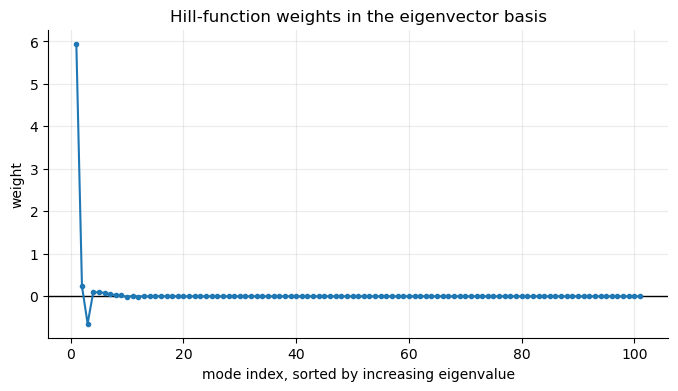

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.axhline(0, color="black", linewidth=1)
ax.plot(weights_table["mode"], weights_table["weight"], marker="o", markersize=3, linewidth=1.5)
ax.set_xlabel("mode index, sorted by increasing eigenvalue")
ax.set_ylabel("weight")
ax.set_title("Hill-function weights in the eigenvector basis")
plt.show()

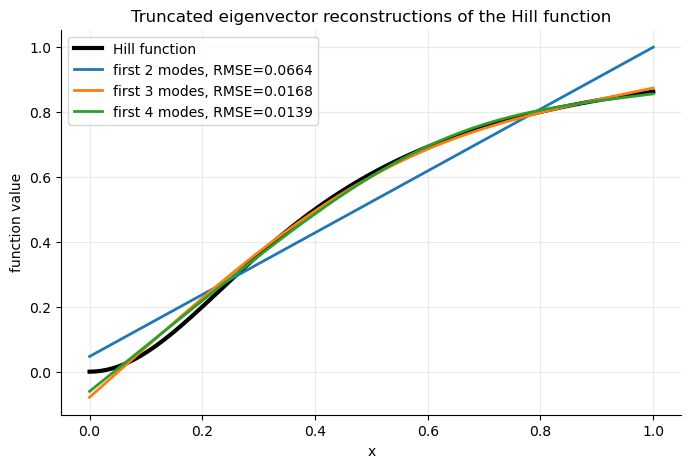

In [8]:
def reconstruct(m):
    return eigvecs[:, :m] @ weights[:m]

reconstructions = {m: reconstruct(m) for m in [2, 3, 4]}

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grid, hill, color="black", linewidth=3, label="Hill function")

for m, yhat in reconstructions.items():
    rmse = np.sqrt(np.mean((hill - yhat) ** 2))
    ax.plot(grid, yhat, linewidth=2, label=f"first {m} modes, RMSE={rmse:.4f}")

ax.set_xlabel("x")
ax.set_ylabel("function value")
ax.set_title("Truncated eigenvector reconstructions of the Hill function")
ax.legend()
plt.show()

## Takeaway

The second-difference penalty separates function space into smooth low-penalty modes and increasingly oscillatory high-penalty modes. The Hill function with $K=0.4$ is smooth on this grid, so most of its visible structure is captured by the first few low-penalty eigenvectors. The 2-mode approximation captures the broad trend, the 3-mode approximation improves the curvature, and the 4-mode approximation already gives a good visual recovery.

## Periodic boundary conditions

The periodic boundary case is especially clean because the second-difference operator becomes a circulant matrix. On an $N$-point ring, define

$$(\Gamma_{\mathrm{per}} f)_j = f_j - 2f_{j+1} + f_{j+2},$$

where the indices are interpreted modulo $N$. The natural eigenvectors are Fourier modes

$$v_j^{(k)} = e^{i q_k j}, \qquad q_k = \frac{2\pi k}{N}, \qquad k=0,1,\ldots,N-1.$$

Applying the periodic second difference to one Fourier mode gives

$$\Gamma_{\mathrm{per}} v^{(k)} = (1 - e^{i q_k})^2 v^{(k)}.$$

Therefore the penalty matrix has eigenvalues

$$\lambda_k(\Gamma_{\mathrm{per}}^T\Gamma_{\mathrm{per}}) = |1-e^{i q_k}|^4 = 16\sin^4\left(\frac{q_k}{2}\right).$$

For small wave number $q$, this behaves like

$$\lambda(q) \sim q^4.$$

This $q^4$ scaling is the main message: the second-difference penalty is extremely weak on long-wavelength Fourier modes and becomes rapidly stronger on high-frequency oscillations.

In [9]:
N = 100
j = np.arange(N)
q = 2 * np.pi * np.arange(N) / N

Gamma_per = np.zeros((N, N))
for row in range(N):
    Gamma_per[row, row] = 1
    Gamma_per[row, (row + 1) % N] = -2
    Gamma_per[row, (row + 2) % N] = 1

periodic_penalty = Gamma_per.T @ Gamma_per
periodic_eigvals_numeric = np.sort(np.linalg.eigvalsh(periodic_penalty))
periodic_eigvals_formula = 16 * np.sin(q / 2)**4
periodic_eigvals_formula_sorted = np.sort(periodic_eigvals_formula)

print(f"Maximum numerical/formula difference: {np.max(np.abs(periodic_eigvals_numeric - periodic_eigvals_formula_sorted)):.2e}")

Maximum numerical/formula difference: 1.42e-14


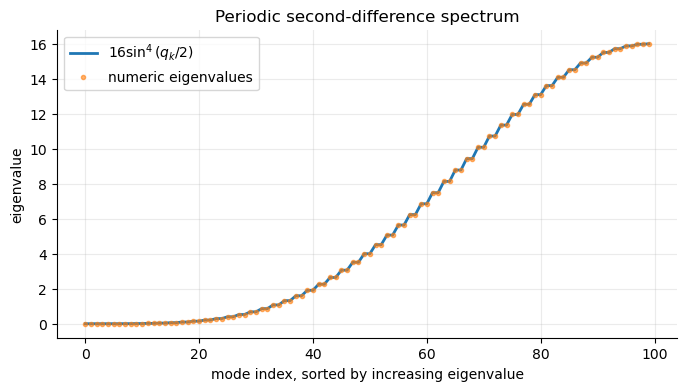

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(N), periodic_eigvals_formula_sorted, linewidth=2, label=r"$16\sin^4(q_k/2)$")
ax.plot(np.arange(N), periodic_eigvals_numeric, ".", alpha=0.6, label="numeric eigenvalues")
ax.set_xlabel("mode index, sorted by increasing eigenvalue")
ax.set_ylabel("eigenvalue")
ax.set_title("Periodic second-difference spectrum")
ax.legend()
plt.show()

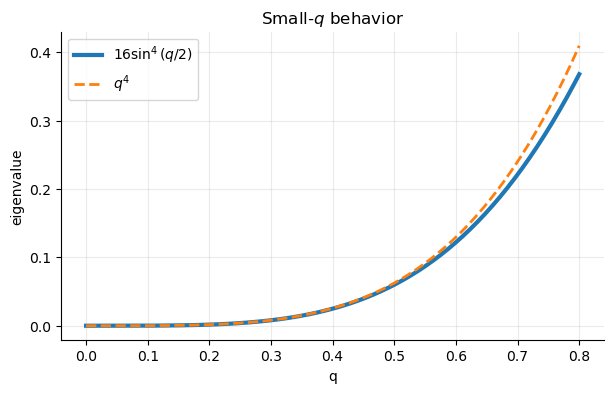

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
q_small = np.linspace(0, 0.8, 200)
lambda_exact = 16 * np.sin(q_small / 2)**4
ax.plot(q_small, lambda_exact, linewidth=3, label=r"$16\sin^4(q/2)$")
ax.plot(q_small, q_small**4, "--", linewidth=2, label=r"$q^4$")
ax.set_xlabel("q")
ax.set_ylabel("eigenvalue")
ax.set_title("Small-$q$ behavior")
ax.legend()
plt.show()

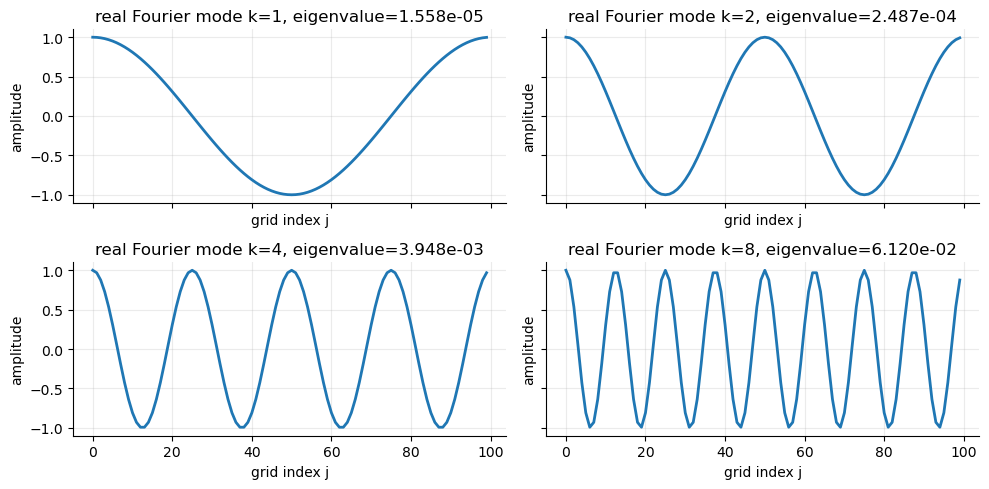

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True, sharey=True)
fourier_modes_to_show = [1, 2, 4, 8]

for ax, k in zip(axes.ravel(), fourier_modes_to_show):
    mode = np.cos(2 * np.pi * k * j / N)
    lam = 16 * np.sin(np.pi * k / N)**4
    ax.plot(j, mode, linewidth=2)
    ax.set_title(f"real Fourier mode k={k}, eigenvalue={lam:.3e}")
    ax.set_xlabel("grid index j")
    ax.set_ylabel("amplitude")

fig.tight_layout()
plt.show()

### Periodic-boundary takeaway

With periodic boundary conditions, the eigenvectors are exactly Fourier modes. The eigenvalue depends only on the wave number: low-frequency modes have very small penalty, approximately $q^4$, while high-frequency modes are penalized much more strongly. This is the clean Fourier-space version of the same smoothing idea seen above.